In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

In [37]:
df=pd.read_csv('heart_failure_clinical_records_dataset.csv')

In [38]:
df.head()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [39]:
df.shape


(299, 13)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [41]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

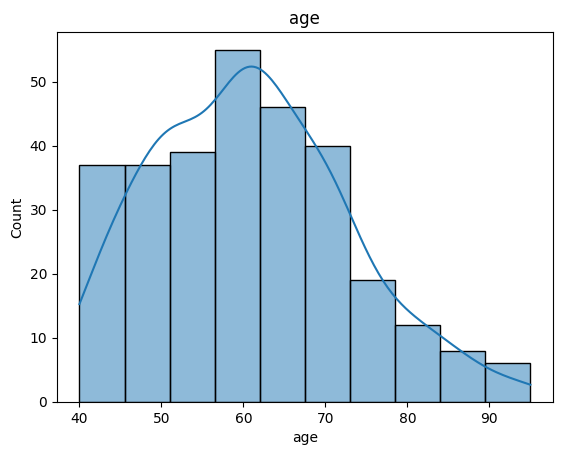

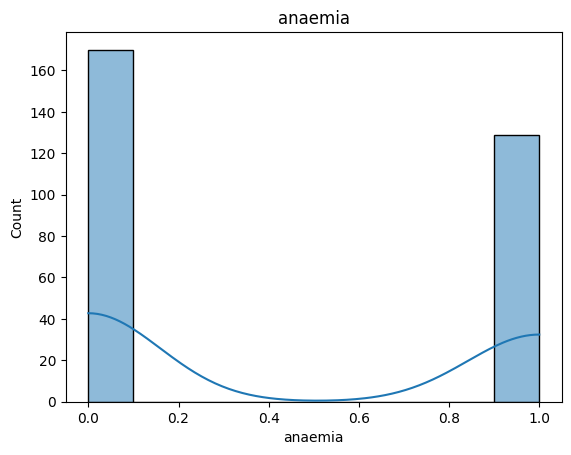

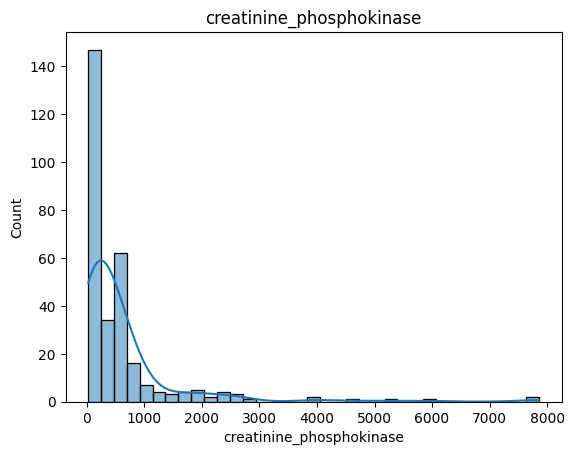

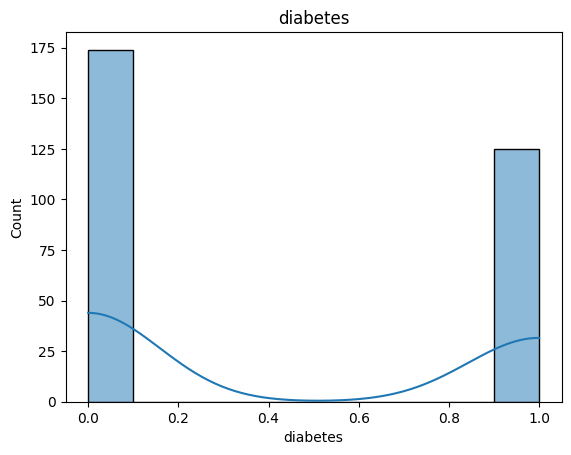

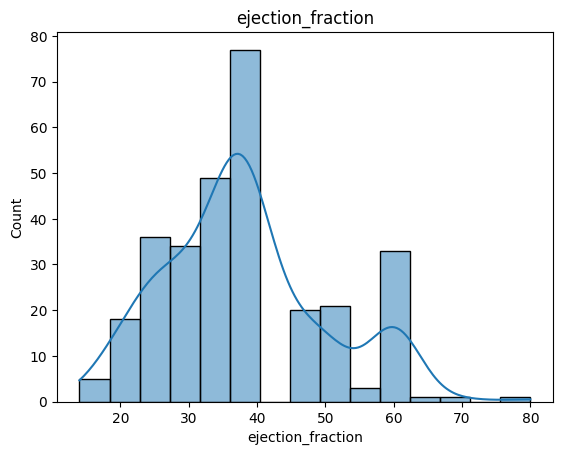

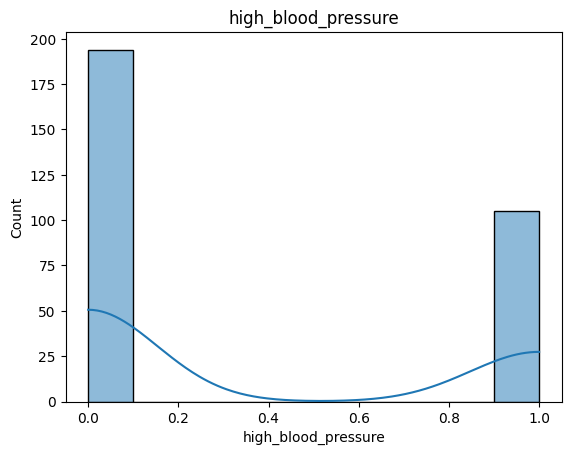

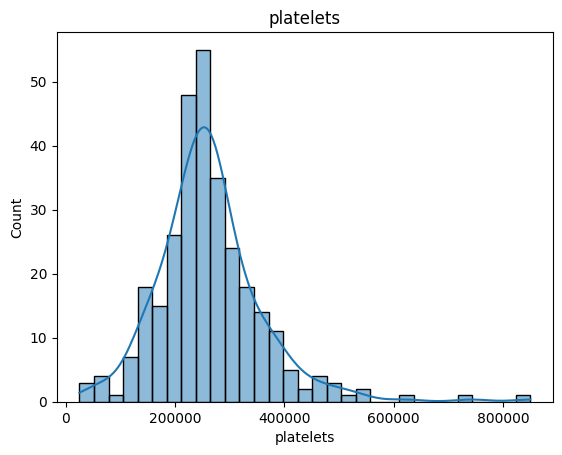

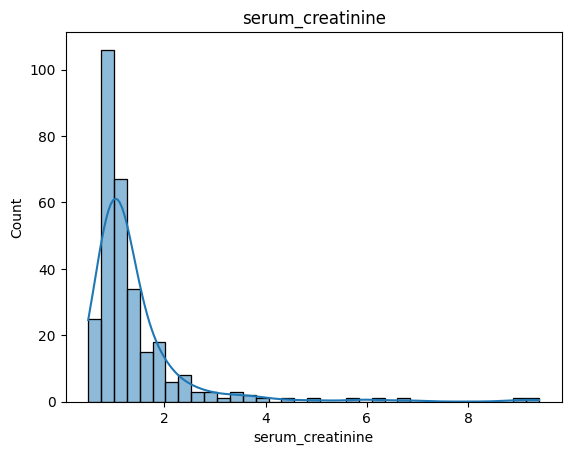

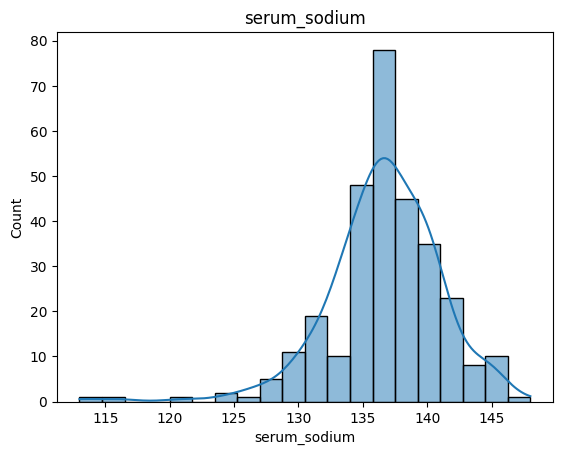

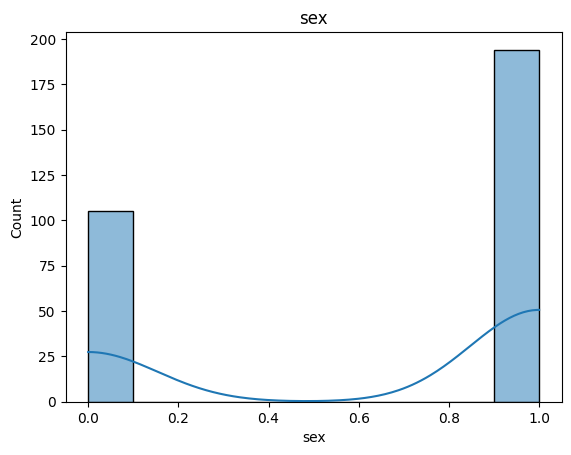

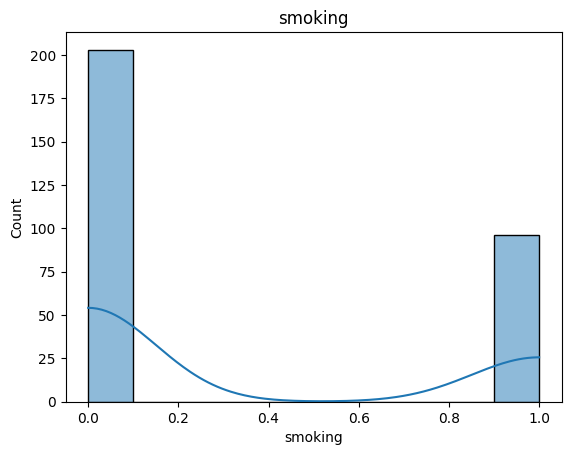

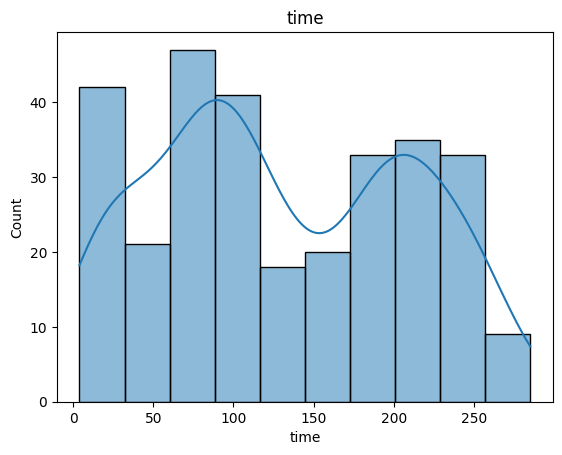

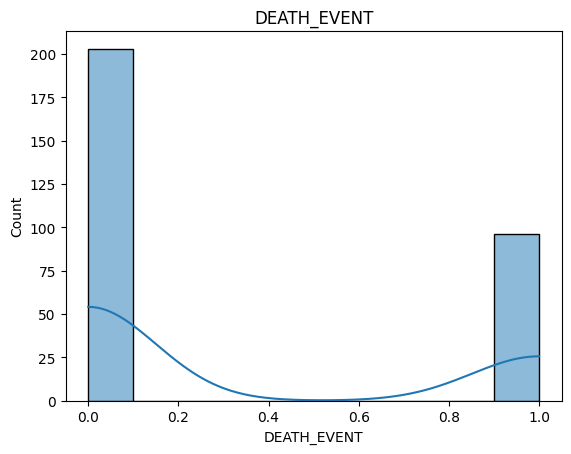

In [42]:
columns=df.select_dtypes(include=np.number).columns

for col in columns:
    plt.figure()
    sns.histplot(df[col],kde=True)
    plt.title(col)
    plt.show()

In [43]:
df.skew()

age                         0.423062
anaemia                     0.278261
creatinine_phosphokinase    4.463110
diabetes                    0.333929
ejection_fraction           0.555383
high_blood_pressure         0.626732
platelets                   1.462321
serum_creatinine            4.455996
serum_sodium               -1.048136
sex                        -0.626732
smoking                     0.770349
time                        0.127803
DEATH_EVENT                 0.770349
dtype: float64

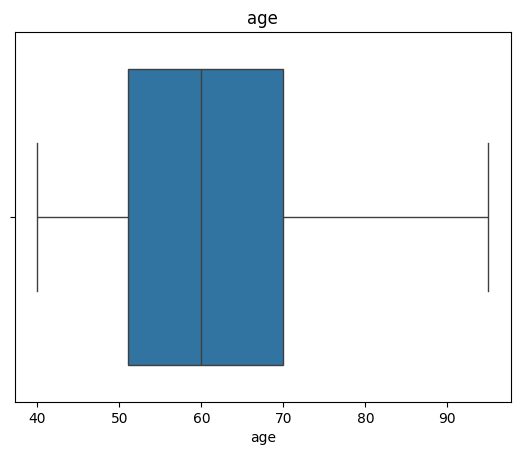

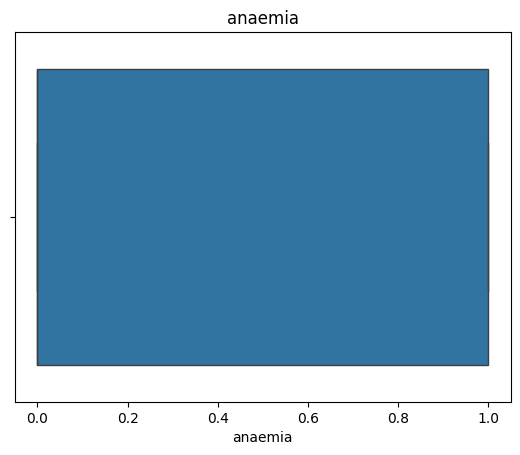

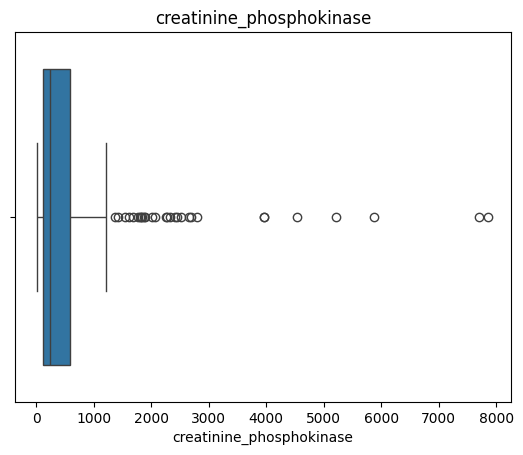

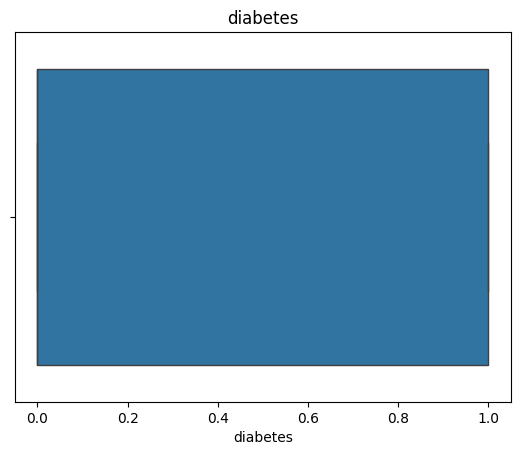

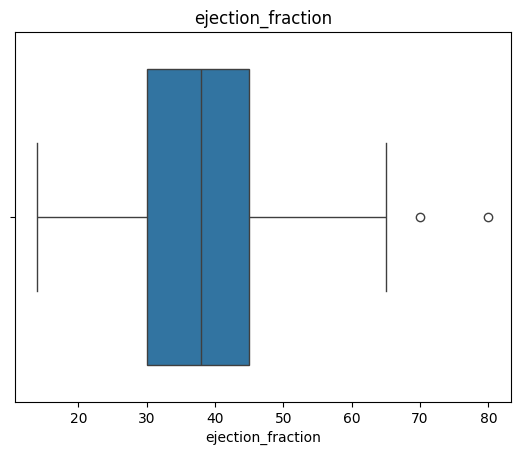

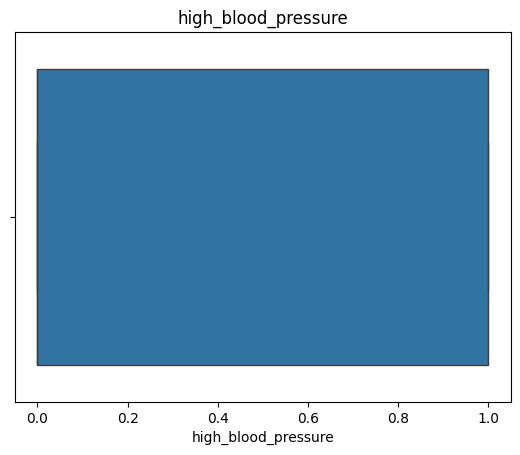

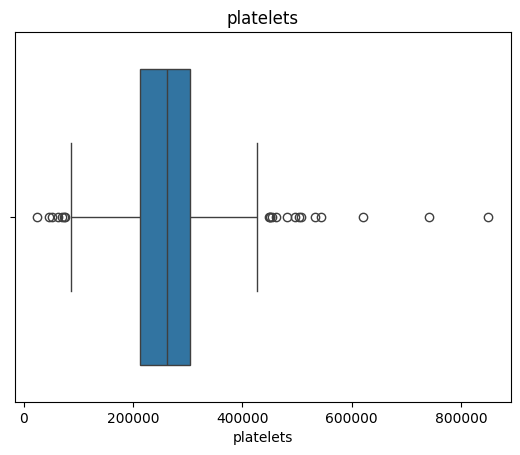

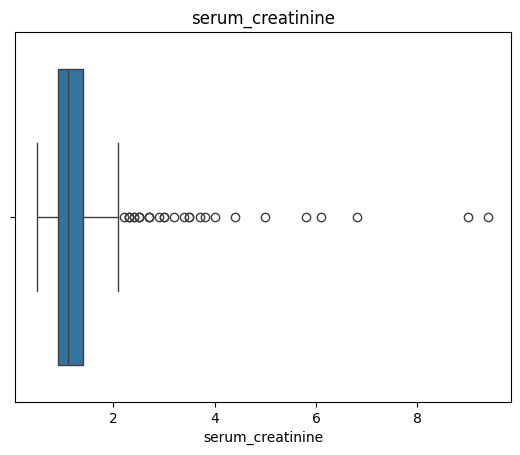

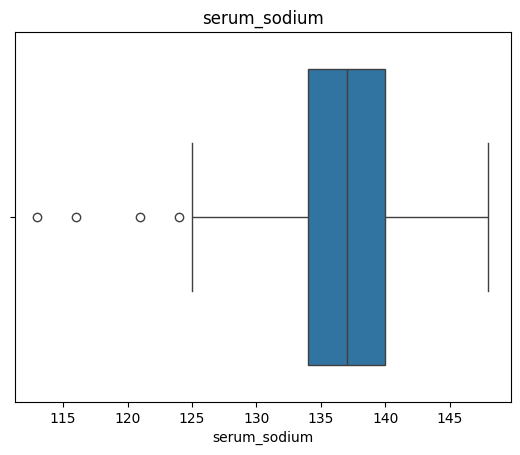

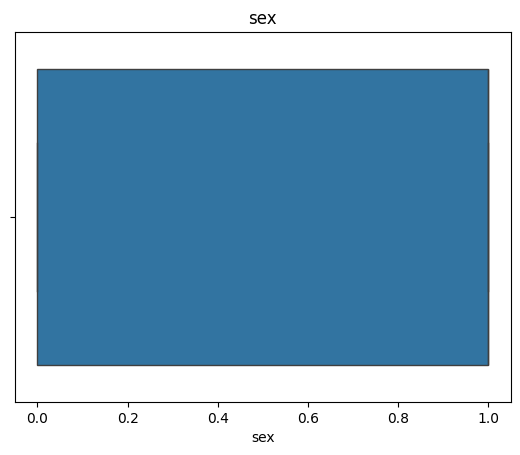

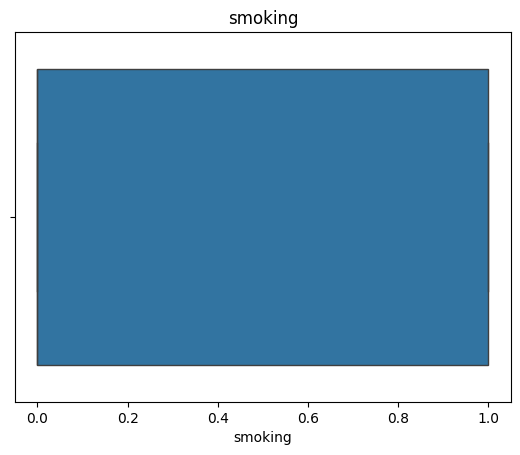

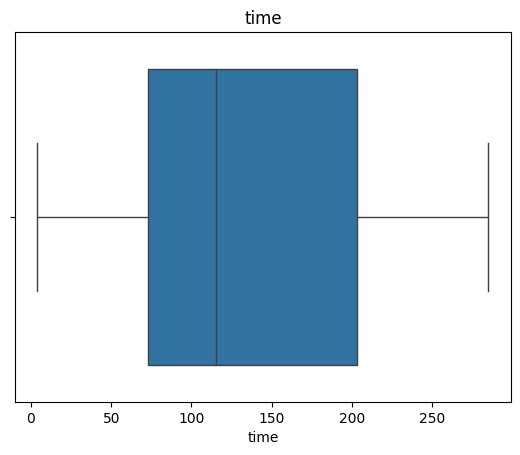

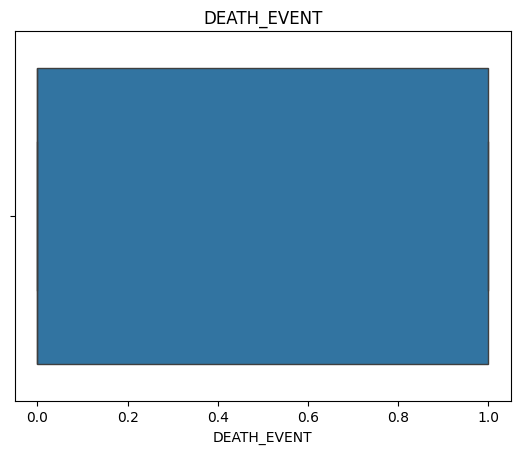

In [44]:
for col in columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [47]:
def iqr_capping(col):
    Q1=col.quantile(0.25)
    Q3=col.quantile(0.75)
    IQR=Q3-Q1

    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR

    return np.clip(col,lower,upper)

In [48]:
df['creatinine_phosphokinase']=iqr_capping(df['creatinine_phosphokinase'])
df['creatinine_phosphokinase']=np.log1p(df['creatinine_phosphokinase'])

In [49]:
df['platelets'] = iqr_capping(df['platelets'])
df['platelets'] = np.log1p(df['platelets'])

In [50]:
df['serum_creatinine'] = iqr_capping(df['serum_creatinine'])
df['serum_creatinine'] = np.log1p(df['serum_creatinine'])

In [51]:
df.skew()

age                         0.423062
anaemia                     0.278261
creatinine_phosphokinase   -0.032822
diabetes                    0.333929
ejection_fraction           0.555383
high_blood_pressure         0.626732
platelets                  -0.954468
serum_creatinine            0.625287
serum_sodium               -1.048136
sex                        -0.626732
smoking                     0.770349
time                        0.127803
DEATH_EVENT                 0.770349
dtype: float64

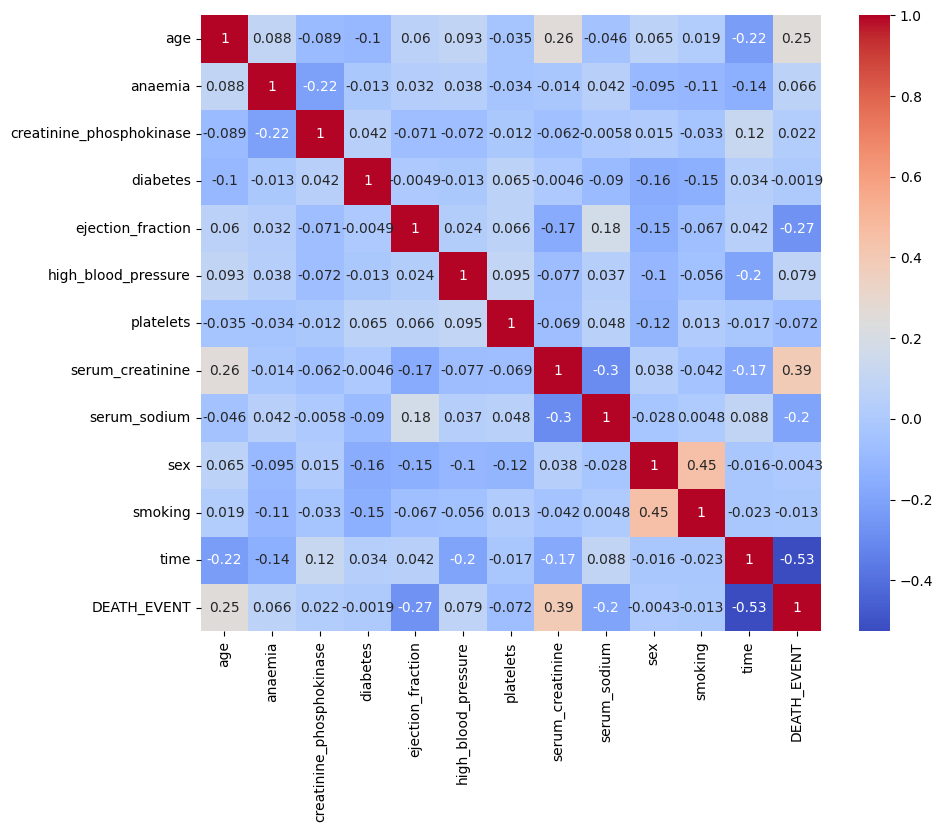

In [52]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

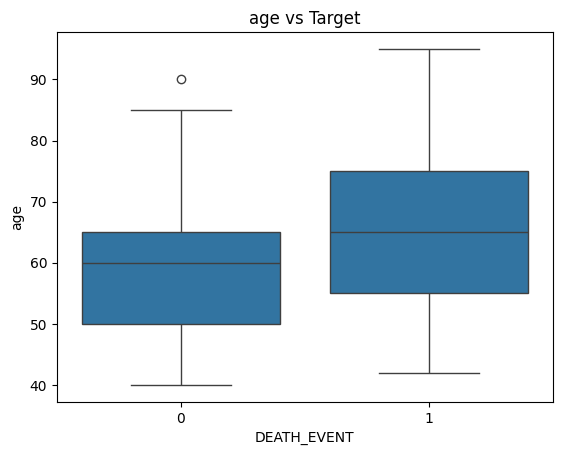

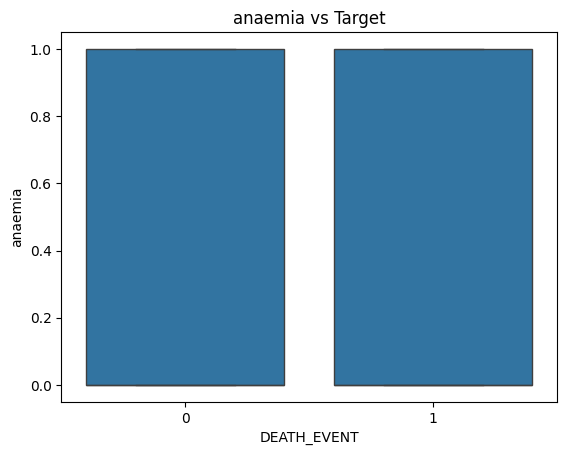

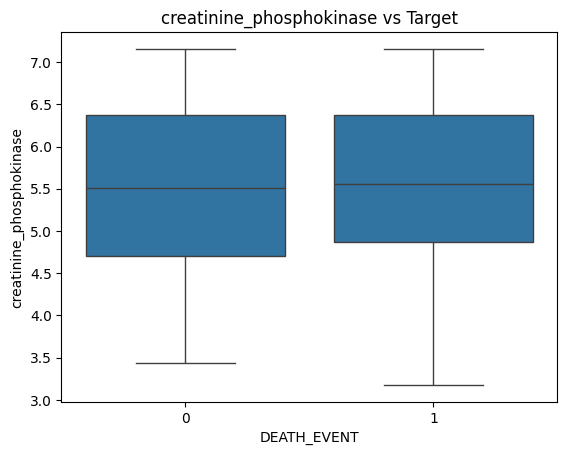

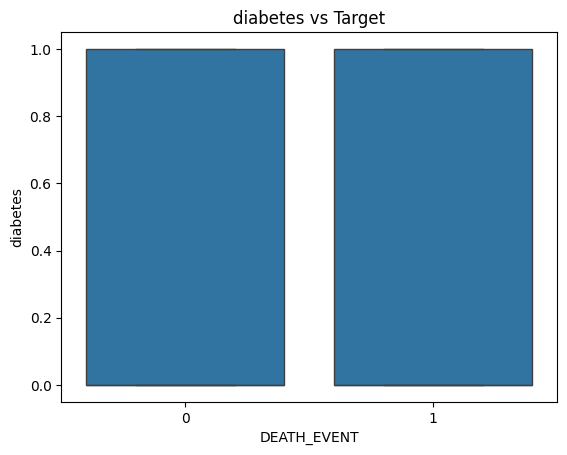

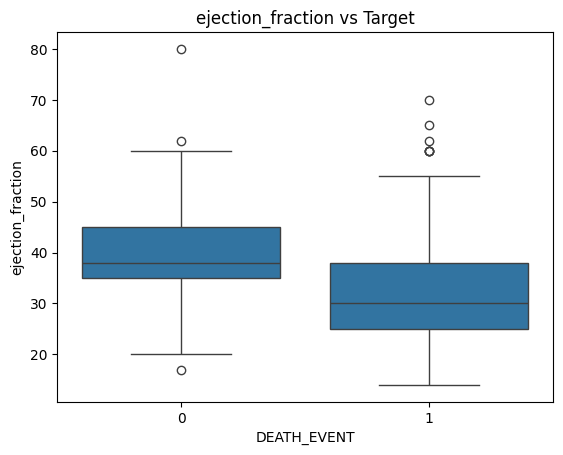

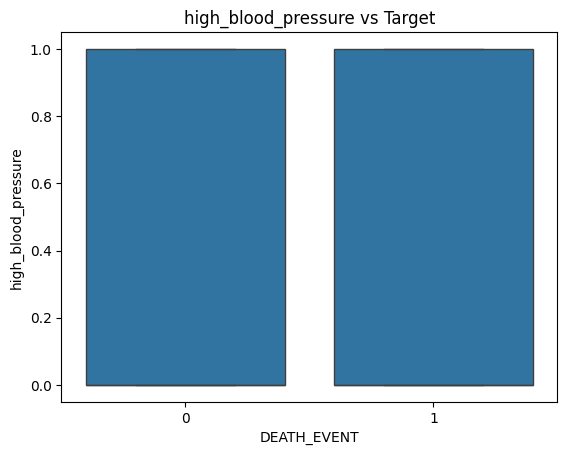

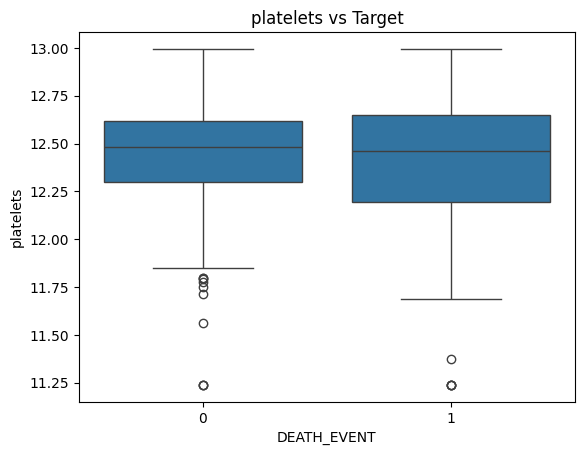

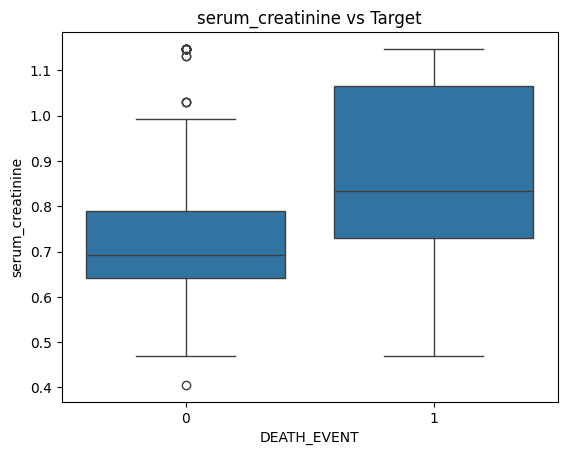

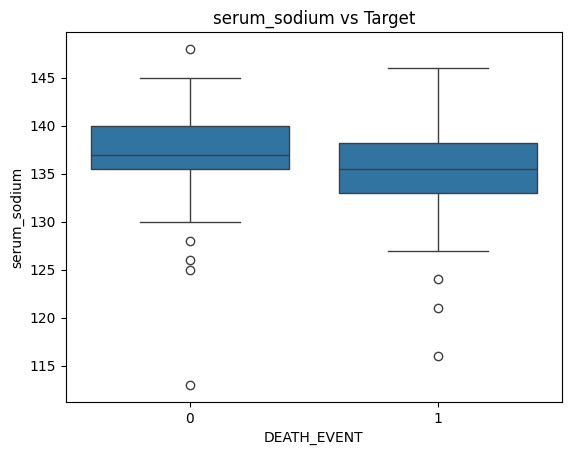

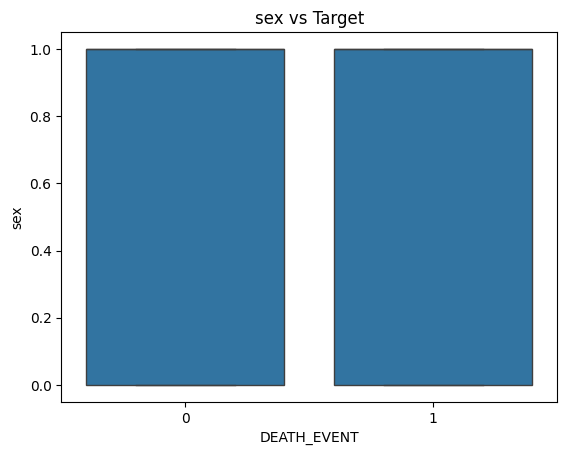

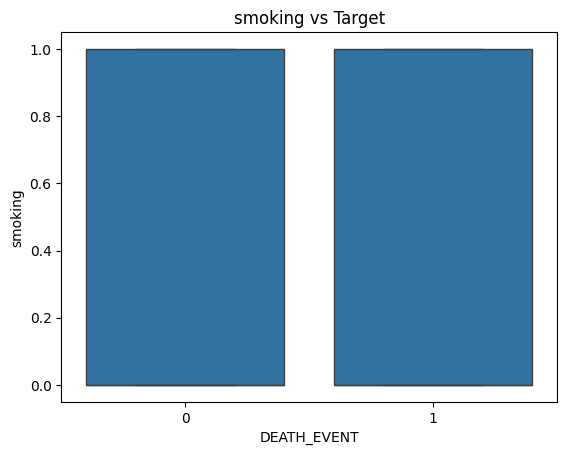

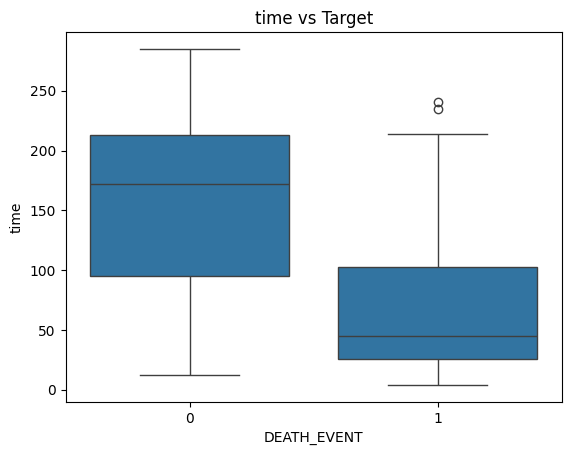

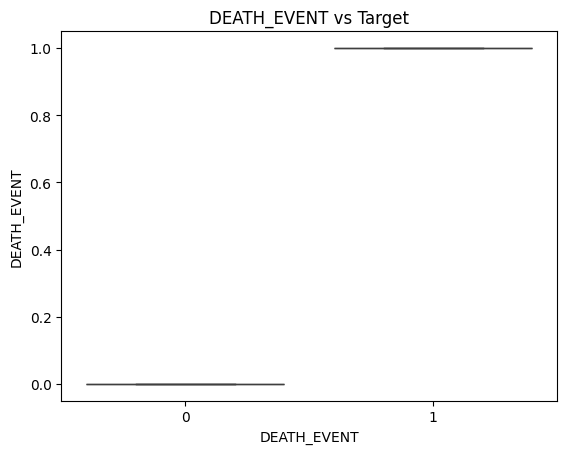

In [53]:
for col in columns:
    sns.boxplot(x='DEATH_EVENT', y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.show()

In [54]:
df.drop('time',axis=1,inplace=True)

In [55]:
x=df.drop('DEATH_EVENT',axis=1)
y=df['DEATH_EVENT']

x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42,stratify=y
)

In [58]:
cols_to_scale=['age','creatinine_phosphokinase','ejection_fraction','platelets','serum_creatinine','serum_sodium']
scaler=StandardScaler()
x_train[cols_to_scale] = scaler.fit_transform(x_train[cols_to_scale])
x_test[cols_to_scale] = scaler.transform(x_test[cols_to_scale])


In [59]:
smote=SMOTE(random_state=42)
x_train,y_train=smote.fit_resample(x_train,y_train)

In [60]:
y_train.value_counts()

DEATH_EVENT
0    162
1    162
Name: count, dtype: int64